# Evaluasi Metrik Segmentasi Glioma

Notebook ini menghitung metrik evaluasi hasil segmentasi terhadap mask referensi binary di folder `Reference`.

Metrik yang dihitung:

- Pixel Accuracy
- Dice Coefficient
- Intersection over Union (IoU)

Catatan: file reference harus memiliki nama dasar yang sama dengan citra pada folder `Glioma`. Contoh: `Glioma/Te-gl_115.jpg` dapat dipasangkan dengan `Reference/Te-gl_115.jpg` atau `Reference/Te-gl_115.png`.

## 1. Import Library

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

%matplotlib inline

## 2. Konfigurasi

In [2]:
REFERENCE_DIR = Path("Reference")
OUTPUT_DIR = Path("Output")
METRICS_DIR = OUTPUT_DIR / "Metrics"

METHOD_DIRS = {
    "KMeans": OUTPUT_DIR / "KMeans",
    "FCM": OUTPUT_DIR / "FCM",
    "GMM": OUTPUT_DIR / "GMM",
}

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp"}
MASK_THRESHOLD = 127

METRICS_DIR.mkdir(parents=True, exist_ok=True)

## 3. Fungsi Bantu

In [3]:
def list_reference_masks(reference_dir: Path) -> list[Path]:
    return sorted(
        path for path in reference_dir.iterdir()
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )


def read_binary_mask(path: Path, threshold: int = MASK_THRESHOLD) -> np.ndarray:
    mask = np.asarray(Image.open(path).convert("L"))
    return mask > threshold


def find_prediction_mask(method_dir: Path, stem: str) -> Path | None:
    for extension in [".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"]:
        candidate = method_dir / f"{stem}{extension}"
        if candidate.exists():
            return candidate
    return None


def resize_mask_if_needed(mask: np.ndarray, target_shape: tuple[int, int], source_path: Path) -> np.ndarray:
    if mask.shape == target_shape:
        return mask
    warnings.warn(
        f"Ukuran mask {source_path} adalah {mask.shape}, diubah ke {target_shape}. "
        "Pastikan reference dibuat dari citra asli yang sama."
    )
    pil_mask = Image.fromarray(mask.astype(np.uint8) * 255)
    resized = pil_mask.resize((target_shape[1], target_shape[0]), Image.Resampling.NEAREST)
    return np.asarray(resized) > 127


def compute_metrics(reference_mask: np.ndarray, prediction_mask: np.ndarray) -> dict[str, float]:
    reference_mask = reference_mask.astype(bool)
    prediction_mask = prediction_mask.astype(bool)

    tp = np.logical_and(prediction_mask, reference_mask).sum()
    tn = np.logical_and(~prediction_mask, ~reference_mask).sum()
    fp = np.logical_and(prediction_mask, ~reference_mask).sum()
    fn = np.logical_and(~prediction_mask, reference_mask).sum()
    total = reference_mask.size

    pixel_accuracy = (tp + tn) / total if total else np.nan
    dice_denominator = (2 * tp + fp + fn)
    iou_denominator = (tp + fp + fn)

    dice = (2 * tp) / dice_denominator if dice_denominator else 1.0
    iou = tp / iou_denominator if iou_denominator else 1.0

    return {
        "Pixel Accuracy": float(pixel_accuracy),
        "Dice Coefficient": float(dice),
        "IoU": float(iou),
        "TP": int(tp),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
    }

## 4. Hitung Metrik Semua Metode

In [4]:
reference_paths = list_reference_masks(REFERENCE_DIR)
if not reference_paths:
    raise FileNotFoundError(
        f"Tidak ada file reference binary di folder {REFERENCE_DIR.resolve()}. "
        "Buat mask reference manual terlebih dahulu dengan nama dasar file yang sama."
    )

records = []
missing_predictions = []

for reference_path in reference_paths:
    reference_mask = read_binary_mask(reference_path)

    for method_name, method_dir in METHOD_DIRS.items():
        prediction_path = find_prediction_mask(method_dir, reference_path.stem)
        if prediction_path is None:
            missing_predictions.append({
                "Reference": reference_path.name,
                "Method": method_name,
                "Expected Folder": str(method_dir),
            })
            continue

        prediction_mask = read_binary_mask(prediction_path)
        prediction_mask = resize_mask_if_needed(prediction_mask, reference_mask.shape, prediction_path)
        metrics = compute_metrics(reference_mask, prediction_mask)

        records.append({
            "Image": reference_path.name,
            "Reference Path": str(reference_path),
            "Prediction Path": str(prediction_path),
            "Method": method_name,
            **metrics,
        })

metrics_df = pd.DataFrame(records)
missing_df = pd.DataFrame(missing_predictions)

if metrics_df.empty:
    raise FileNotFoundError("Tidak ada pasangan reference dan hasil segmentasi yang ditemukan.")

metrics_path = METRICS_DIR / "segmentation_metrics.csv"
missing_path = METRICS_DIR / "missing_predictions.csv"

metrics_df.to_csv(metrics_path, index=False)
if not missing_df.empty:
    missing_df.to_csv(missing_path, index=False)

metrics_df

,Image,Reference Path,Prediction Path,Method,Pixel Accuracy,Dice Coefficient,IoU,TP,TN,FP,FN
0,Te-gl_115.png,Reference\Te-gl_115.png,Output\KMeans\Te-gl_115.png,KMeans,0.998474,0.954350,0.912685,2216,136490,67,145
1,Te-gl_115.png,Reference\Te-gl_115.png,Output\FCM\Te-gl_115.png,FCM,0.998488,0.954800,0.913509,2218,136490,67,143
2,Te-gl_115.png,Reference\Te-gl_115.png,Output\GMM\Te-gl_115.png,GMM,0.998028,0.942582,0.891399,2249,136395,162,112
3,Te-gl_14.png,Reference\Te-gl_14.png,Output\KMeans\Te-gl_14.png,KMeans,0.999084,0.962347,0.927427,3067,258837,73,167
4,Te-gl_14.png,Reference\Te-gl_14.png,Output\FCM\Te-gl_14.png,FCM,0.999107,0.963150,0.928919,3058,258852,58,176
5,Te-gl_14.png,Reference\Te-gl_14.png,Output\GMM\Te-gl_14.png,GMM,0.999077,0.962128,0.927021,3074,258828,82,160
6,Te-gl_62.png,Reference\Te-gl_62.png,Output\KMeans\Te-gl_62.png,KMeans,0.966752,0.670471,0.504293,4053,111789,1,3983
7,Te-gl_62.png,Reference\Te-gl_62.png,Output\FCM\Te-gl_62.png,FCM,0.966326,0.664784,0.497885,4001,111790,0,4035
8,Te-gl_62.png,Reference\Te-gl_62.png,Output\GMM\Te-gl_62.png,GMM,0.966743,0.670361,0.504168,4052,111789,1,3984
9,Te-gl_66.png,Reference\Te-gl_66.png,Output\KMeans\Te-gl_66.png,KMeans,0.985577,0.742173,0.590043,3129,145428,62,2112


## 5. Ringkasan Per Metode

In [5]:
metric_columns = ["Pixel Accuracy", "Dice Coefficient", "IoU"]

summary_df = (
    metrics_df
    .groupby("Method")[metric_columns]
    .agg(["mean", "std", "min", "max"])
    .round(6)
)

summary_path = METRICS_DIR / "summary_metrics.csv"
summary_df.to_csv(summary_path)
summary_df

Pixel Accuracy                               Dice Coefficient  \
                 mean       std       min       max             mean   
Method                                                                 
FCM          0.989471  0.014101  0.966326  0.999107         0.846705   
GMM          0.989376  0.013863  0.966743  0.999077         0.843147   
KMeans       0.989549  0.013920  0.966752  0.999084         0.847592   

                                           IoU                                
             std       min       max      mean       std       min       max  
Method                                                                        
FCM     0.135185  0.664784  0.963150  0.752579  0.196644  0.497885  0.928919  
GMM     0.132136  0.670361  0.962128  0.746325  0.191664  0.504168  0.927021  
KMeans  0.133018  0.670471  0.962347  0.753397  0.194075  0.504293  0.927427

## 6. Visualisasi Perbandingan

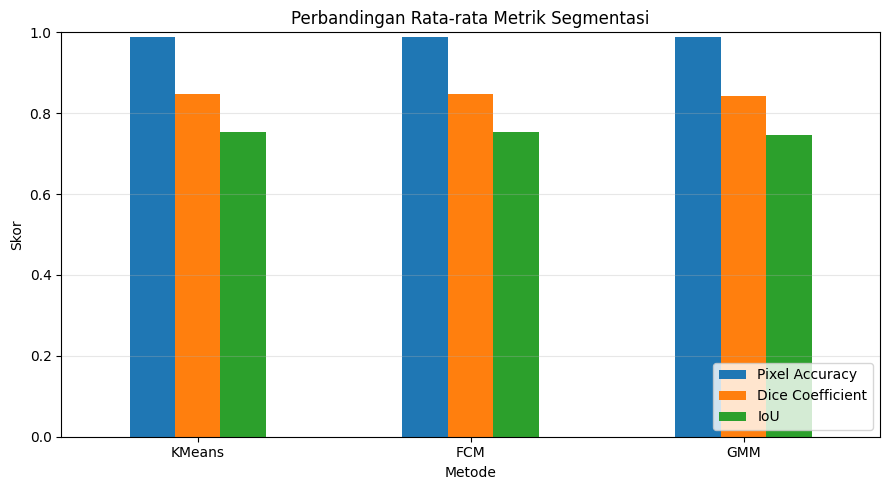

Detail metrik disimpan di: Output\Metrics\segmentation_metrics.csv
Ringkasan metrik disimpan di: Output\Metrics\summary_metrics.csv
Grafik perbandingan disimpan di: Output\Metrics\metrics_comparison.png


In [6]:
mean_metrics = metrics_df.groupby("Method")[metric_columns].mean().loc[["KMeans", "FCM", "GMM"]]

ax = mean_metrics.plot(kind="bar", figsize=(9, 5), ylim=(0, 1), rot=0)
ax.set_title("Perbandingan Rata-rata Metrik Segmentasi")
ax.set_xlabel("Metode")
ax.set_ylabel("Skor")
ax.grid(axis="y", alpha=0.3)
ax.legend(loc="lower right")

plt.tight_layout()
plot_path = METRICS_DIR / "metrics_comparison.png"
plt.savefig(plot_path, dpi=200)
plt.show()

print(f"Detail metrik disimpan di: {metrics_path}")
print(f"Ringkasan metrik disimpan di: {summary_path}")
print(f"Grafik perbandingan disimpan di: {plot_path}")
if not missing_df.empty:
    print(f"Daftar hasil segmentasi yang belum ditemukan disimpan di: {missing_path}")